In [9]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


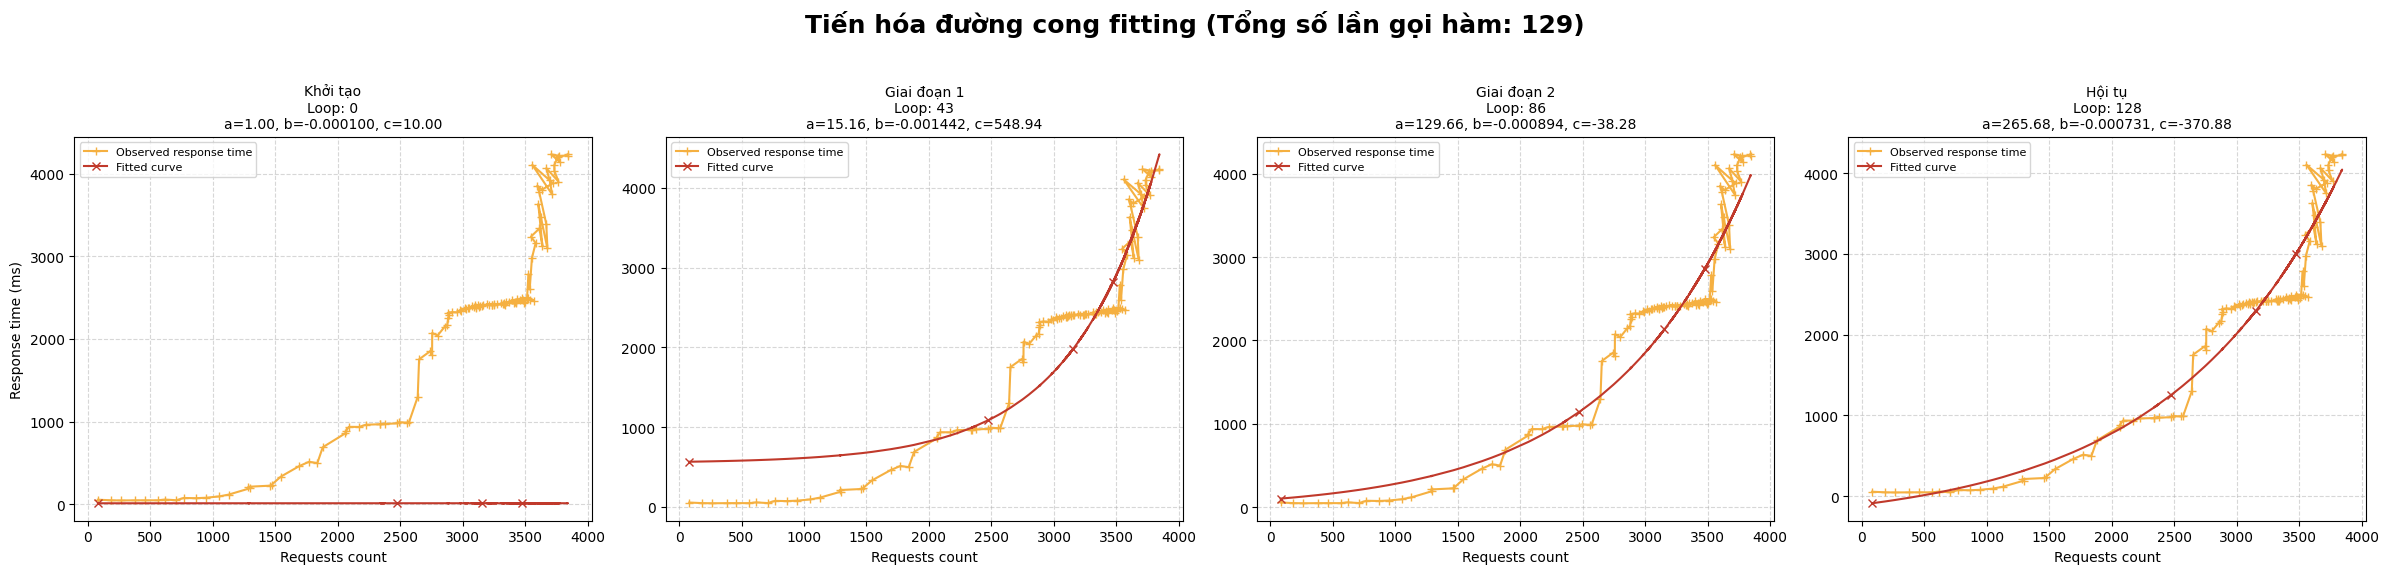


📊 KẾT QUẢ KIỂM CHỨNG MÔ HÌNH (GOODNESS-OF-FIT):
Chỉ số R-squared (R²): 0.9315
Sai số RMSE: 320.1372 ms
✅ Nhận xét: Mô hình khớp rất tốt với dữ liệu thực tế.

✅ THAM SỐ CUỐI CÙNG CHO BÀI BÁO:
a = 265.68214 (Hệ số biên độ)
b = -0.0007312 (Hệ số bão hòa)
c = -370.87584 (Độ trễ cơ sở - Baseline)


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Cấu hình
FILE_PATH = '../../stress_test_frontend/test2/master_dataset2.csv'
df = pd.read_csv(FILE_PATH)
x_data = df['Requests'].values
y_data = df['P95_RT'].values

# 2. Định nghĩa mô hình và biến đếm
global_history = []
loop_counter = 0

def exponential_model(x, a, b, c):
    global loop_counter
    # Ghi lại tham số và tăng đếm vòng lặp
    current_params = [a, b, c]
    if not global_history or global_history[-1] != current_params:
        global_history.append({'params': current_params, 'loop': loop_counter})
    loop_counter += 1
    return a * np.exp(-b * x) + c

# 3. Chạy khớp đường cong
p0 = [1.0, -0.0001, 10.0]
popt_final, _ = curve_fit(exponential_model, x_data, y_data, p0=p0, maxfev=100000)

# 4. Lấy 4 mốc để quan sát
n_history = len(global_history)
indices = [0, n_history // 3, 2 * (n_history // 3), -1] 
stages = [global_history[i] for i in indices]
stage_names = ["Khởi tạo", "Giai đoạn 1", "Giai đoạn 2", "Hội tụ"]

# 5. Vẽ đồ thị so sánh 4 giai đoạn với phong cách bạn yêu cầu
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle(f'Tiến hóa đường cong fitting (Tổng số lần gọi hàm: {loop_counter})', fontsize=18, fontweight='bold')

for i, ax in enumerate(axes):
    params = stages[i]['params']
    loop = stages[i]['loop']
    y_fit = exponential_model(x_data, *params)
    
    # 1. Đường thực tế (Line plot màu cam - #f5b041, marker '+')
    ax.plot(x_data, y_data, label='Observed response time', color='#f5b041', marker='+', linewidth=1.5)
    
    # 2. Đường dự đoán (Màu đỏ sậm - #c0392b, marker 'x', markevery=30)
    ax.plot(x_data, y_fit, label='Fitted curve', color='#c0392b', marker='x', markevery=30, linestyle='-', linewidth=1.5)
    
    # Định dạng
    ax.set_title(f"{stage_names[i]}\nLoop: {loop}\na={params[0]:.2f}, b={params[1]:.6f}, c={params[2]:.2f}", fontsize=10)
    ax.set_xlabel('Requests count')
    if i == 0: ax.set_ylabel('Response time (ms)')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('Process_Fitting_Custom_Colors.png', dpi=300)
plt.show()

# 5.5 Kiểm chứng mô hình (Validation)
from sklearn.metrics import r2_score, mean_squared_error

# Tính toán dự báo trên tập dữ liệu gốc với tham số cuối cùng
y_pred = exponential_model(x_data, *popt_final)

# Tính toán các chỉ số thống kê
r2 = r2_score(y_data, y_pred)
rmse = np.sqrt(mean_squared_error(y_data, y_pred))

# In kết quả kiểm chứng để đưa vào báo cáo
print("\n" + "="*40)
print("📊 KẾT QUẢ KIỂM CHỨNG MÔ HÌNH (GOODNESS-OF-FIT):")
print(f"Chỉ số R-squared (R²): {r2:.4f}")
print(f"Sai số RMSE: {rmse:.4f} ms")

if r2 > 0.8:
    print("✅ Nhận xét: Mô hình khớp rất tốt với dữ liệu thực tế.")
else:
    print("⚠️ Nhận xét: Mô hình khớp chưa cao, hãy kiểm tra lại dữ liệu nhiễu.")
print("="*40 + "\n")

# 6. In kết quả cuối cùng ra màn hình
print("="*40)
print(f"✅ THAM SỐ CUỐI CÙNG CHO BÀI BÁO:")
print(f"a = {popt_final[0]:.5f} (Hệ số biên độ)")
print(f"b = {popt_final[1]:.7f} (Hệ số bão hòa)")
print(f"c = {popt_final[2]:.5f} (Độ trễ cơ sở - Baseline)")
print("="*40)

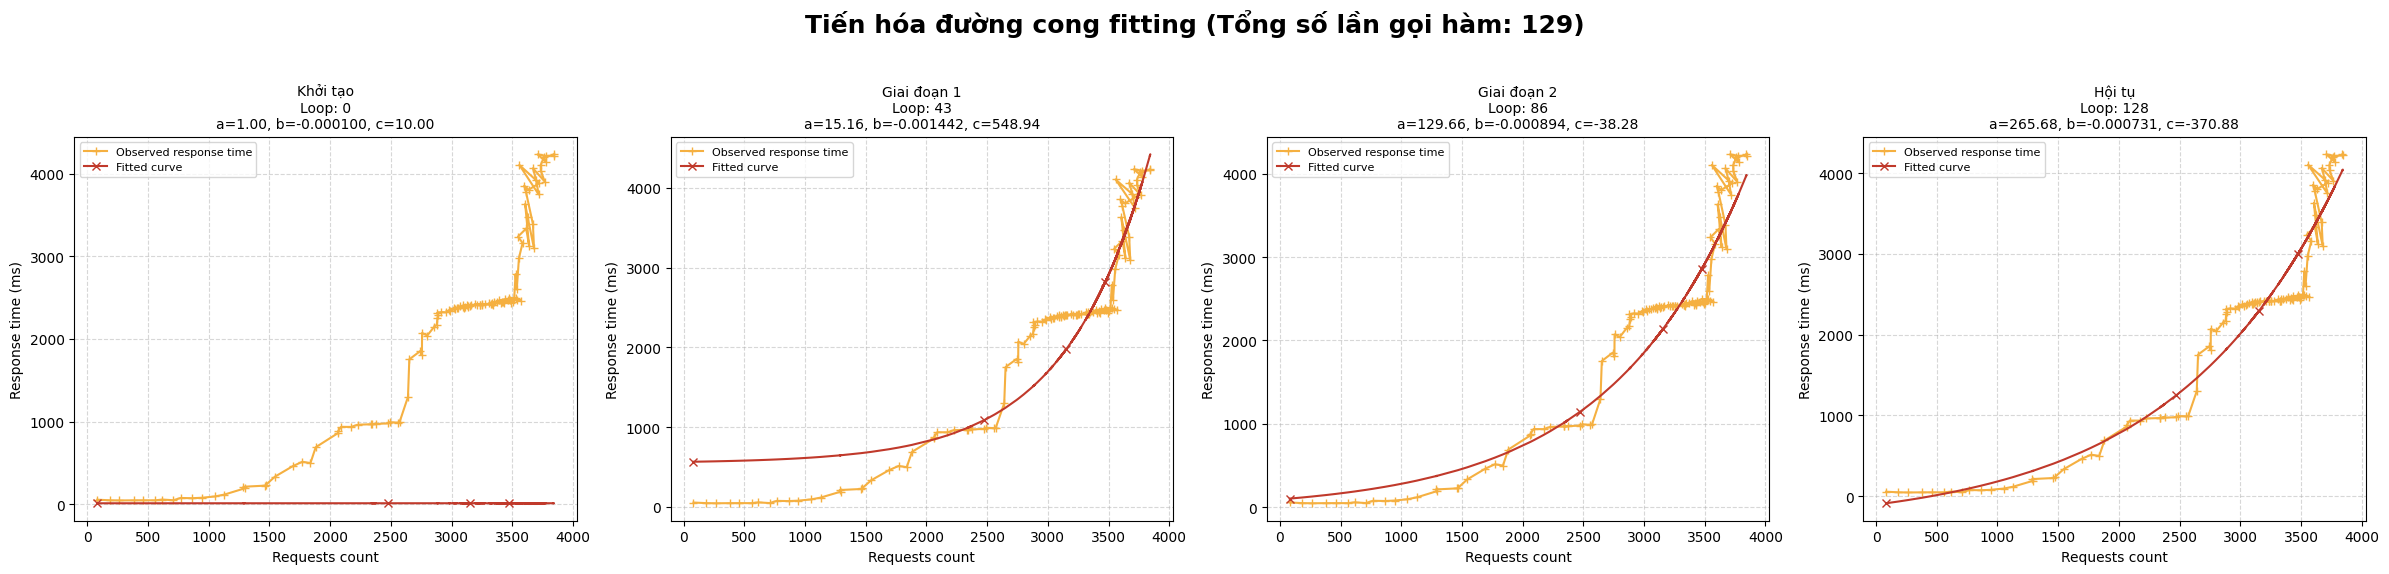


📊 KẾT QUẢ KIỂM CHỨNG MÔ HÌNH (GOODNESS-OF-FIT):
Chỉ số R-squared (R²): 0.9315
Sai số RMSE: 320.1372 ms
✅ Nhận xét: Mô hình khớp rất tốt với dữ liệu thực tế.

✅ THAM SỐ CUỐI CÙNG CHO BÀI BÁO:
a = 265.68214
b = -0.0007312
c = -370.87584


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ============================================================
# 1. CẤU HÌNH
# ============================================================

FILE_PATH = '../../stress_test_frontend/test2/master_dataset2.csv'

df = pd.read_csv(FILE_PATH)

x_data = df['Requests'].values
y_data = df['P95_RT'].values


# ============================================================
# 2. ĐỊNH NGHĨA MÔ HÌNH VÀ BIẾN ĐẾM
# ============================================================

global_history = []
loop_counter = 0


def exponential_model(x, a, b, c):
    global loop_counter

    # Ghi lại tham số và tăng đếm vòng lặp
    current_params = [a, b, c]

    if not global_history or global_history[-1] != current_params:
        global_history.append({
            'params': current_params,
            'loop': loop_counter
        })

    loop_counter += 1

    return a * np.exp(-b * x) + c


# ============================================================
# 3. CHẠY KHỚP ĐƯỜNG CONG
# ============================================================

p0 = [1.0, -0.0001, 10.0]

popt_final, _ = curve_fit(
    exponential_model,
    x_data,
    y_data,
    p0=p0,
    maxfev=100000
)


# ============================================================
# 4. LẤY 4 MỐC ĐỂ QUAN SÁT
# ============================================================

n_history = len(global_history)

indices = [
    0,
    n_history // 3,
    2 * (n_history // 3),
    -1
]

stages = [
    global_history[i]
    for i in indices
]

stage_names = [
    "Khởi tạo",
    "Giai đoạn 1",
    "Giai đoạn 2",
    "Hội tụ"
]


# ============================================================
# 5. VẼ ĐỒ THỊ SO SÁNH 4 GIAI ĐOẠN
# ============================================================

fig, axes = plt.subplots(
    1,
    4,
    figsize=(24, 6)
)

fig.suptitle(
    f'Tiến hóa đường cong fitting '
    f'(Tổng số lần gọi hàm: {loop_counter})',
    fontsize=18,
    fontweight='bold'
)


for i, ax in enumerate(axes):

    params = stages[i]['params']
    loop = stages[i]['loop']

    # Đường fitting ở giai đoạn hiện tại
    y_fit = exponential_model(
        x_data,
        *params
    )

    # --------------------------------------------------------
    # 1. Đường thực tế
    # --------------------------------------------------------

    ax.plot(
        x_data,
        y_data,
        label='Observed response time',
        color='#f5b041',
        marker='+',
        linewidth=1.5
    )

    # --------------------------------------------------------
    # 2. Đường fitting
    # --------------------------------------------------------

    ax.plot(
        x_data,
        y_fit,
        label='Fitted curve',
        color='#c0392b',
        marker='x',
        markevery=30,
        linestyle='-',
        linewidth=1.5
    )

    # --------------------------------------------------------
    # 3. Tiêu đề
    # --------------------------------------------------------

    ax.set_title(
        f"{stage_names[i]}\n"
        f"Loop: {loop}\n"
        f"a={params[0]:.2f}, "
        f"b={params[1]:.6f}, "
        f"c={params[2]:.2f}",
        fontsize=10
    )

    # --------------------------------------------------------
    # 4. Nhãn trục X
    # --------------------------------------------------------

    ax.set_xlabel(
        'Requests count'
    )

    # --------------------------------------------------------
    # 5. Nhãn trục Y
    # CẢ 4 BIỂU ĐỒ ĐỀU CÓ
    # --------------------------------------------------------

    ax.set_ylabel(
        'Response time (ms)'
    )

    # --------------------------------------------------------
    # 6. Grid
    # --------------------------------------------------------

    ax.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

    # --------------------------------------------------------
    # 7. Chú thích
    # --------------------------------------------------------

    ax.legend(
        loc='upper left',
        fontsize=8
    )


# ============================================================
# 6. CĂN CHỈNH VÀ LƯU HÌNH
# ============================================================

plt.tight_layout(
    rect=[0, 0.03, 1, 0.95]
)

plt.savefig(
    'Process_Fitting_Custom_Colors.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 7. KIỂM CHỨNG MÔ HÌNH (VALIDATION)
# ============================================================

from sklearn.metrics import r2_score, mean_squared_error


# Dự báo với tham số cuối cùng
y_pred = exponential_model(
    x_data,
    *popt_final
)


# Tính R²
r2 = r2_score(
    y_data,
    y_pred
)


# Tính RMSE
rmse = np.sqrt(
    mean_squared_error(
        y_data,
        y_pred
    )
)


# ============================================================
# 8. IN KẾT QUẢ KIỂM CHỨNG
# ============================================================

print("\n" + "=" * 40)

print(
    "📊 KẾT QUẢ KIỂM CHỨNG MÔ HÌNH "
    "(GOODNESS-OF-FIT):"
)

print(
    f"Chỉ số R-squared (R²): {r2:.4f}"
)

print(
    f"Sai số RMSE: {rmse:.4f} ms"
)


if r2 > 0.8:

    print(
        "✅ Nhận xét: Mô hình khớp rất tốt "
        "với dữ liệu thực tế."
    )

else:

    print(
        "⚠️ Nhận xét: Mô hình khớp chưa cao, "
        "hãy kiểm tra lại dữ liệu nhiễu."
    )

print("=" * 40 + "\n")


# ============================================================
# 9. IN THAM SỐ CUỐI CÙNG
# ============================================================

print("=" * 40)

print(
    "✅ THAM SỐ CUỐI CÙNG CHO BÀI BÁO:"
)

print(
    f"a = {popt_final[0]:.5f}"
)

print(
    f"b = {popt_final[1]:.7f}"
)

print(
    f"c = {popt_final[2]:.5f}"
)

print("=" * 40)